# Plot tree accuracy vs num of MS targets (downsample)
- Goal is to compare different probe sets with different types of microsatellite
- This notebook compares homopolymer 10-14bp vs 15-50bp from two probe sets

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns
import glob
import re
import os

## Preprocessing

```bash
#!/bin/bash
nextflow run ~/software/RETrace2/main.nf \
            --samplesheet 20230117_HCT116_1nt12k10to14bp_samplesheet.csv \
            --output_dir results_1nt12k10-14bp_500targets_minqual0 \
            --output_prefix 20230117_HCT116_1nt12k10-14bp \
            --genome_base ~/Projects/GenomeDB \
            --genome hg38 \
            --target_bed /home/tcheng/software/RETrace/Data/Probe/TW_order.1nt10-14bp.12000probes.info.HipSTR.bed \
            --min_targets 500 \
            -resume \
            -profile docker \
            --min_qual 0 \



nextflow run ~/software/RETrace2/main.nf \
            --samplesheet 20230117_HCT116_1nt12k15to50bp_samplesheet.csv \
            --output_dir results_1nt12k15-50bp_500targets_minqual0 \
            --output_prefix 20230117_HCT116_1nt12k15-50bp \
            --genome_base ~/Projects/GenomeDB \
            --genome hg38 \
            --target_bed /home/tcheng/software/RETrace/Data/Probe/TW_order_hg38.1nt.12472probes.info.HipSTR.bed \
            --min_targets 500 \
            -resume \
            -profile docker \
            --min_qual 0 \
```

# Circular Phylogenetic Trees
- Display circular tree visualizations for the different probe sets



Homopolymer 10-14bp Circular Tree:


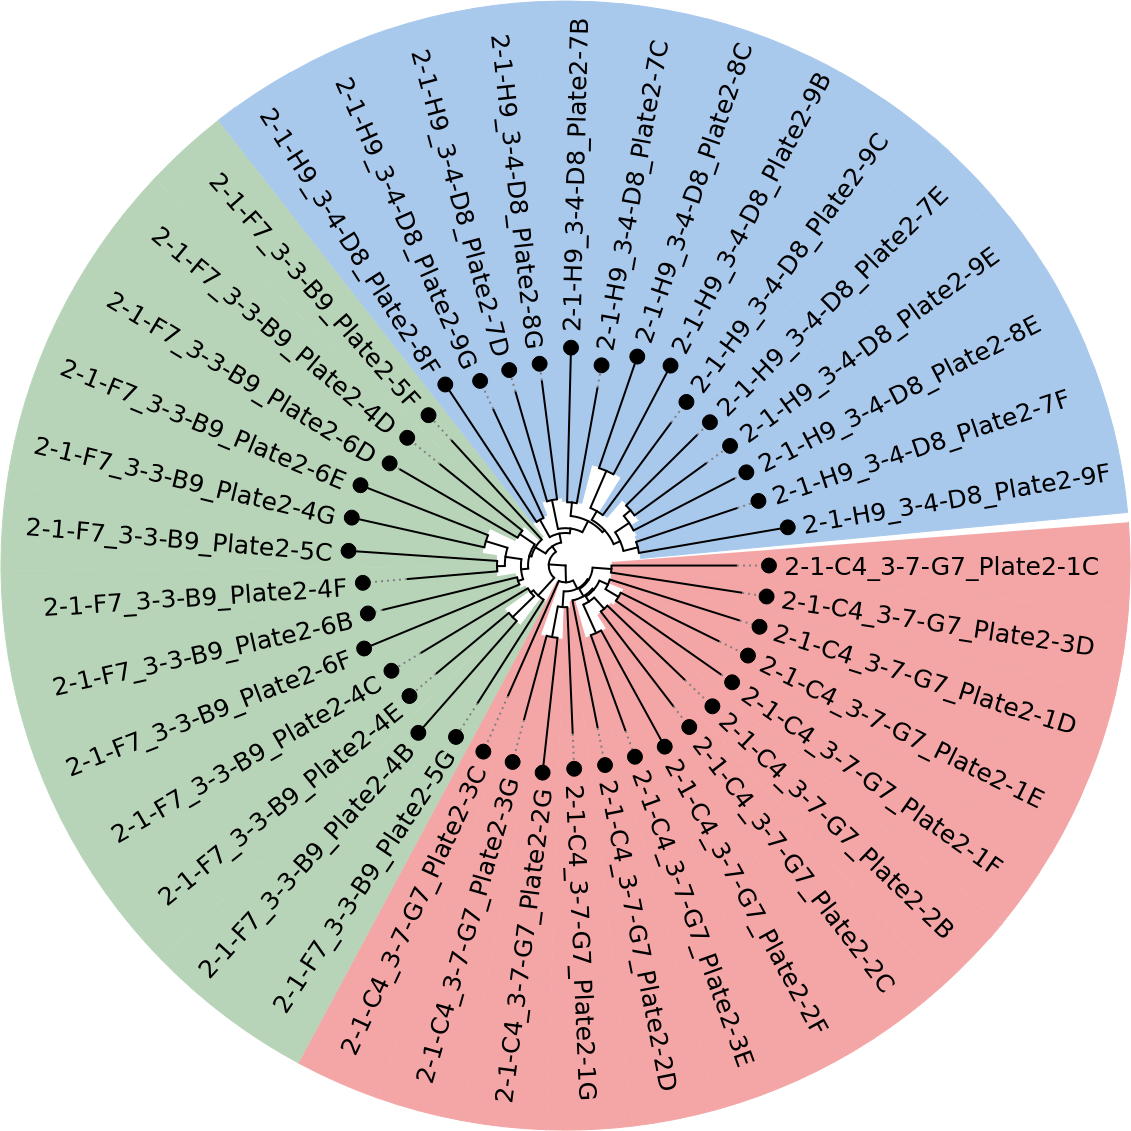


Homopolymer 15-50bp Circular Tree:


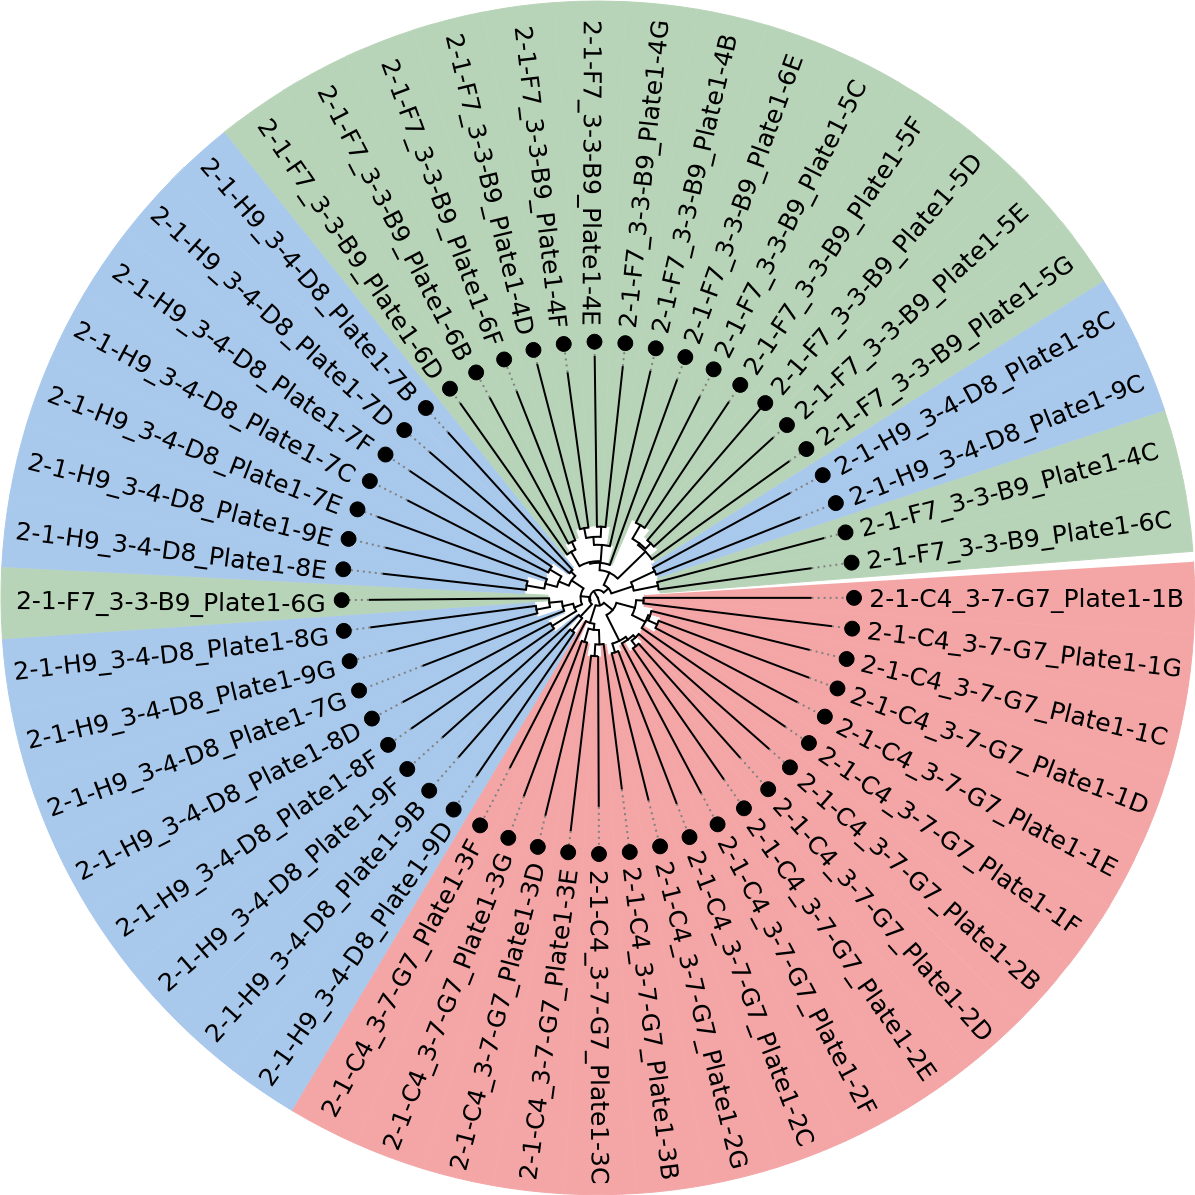

In [3]:
# Display circular phylogenetic trees if available
from IPython.display import Image
import os

# Define potential tree image paths based on your data structure
tree_paths = {
    'Homopolymer 10-14bp': '/home/tcheng/Projects/RETrace/20230117_NovaSeqSP_HCT116_1nt12k_10-14bp_Nextflow/20230117_HCT116_1nt12k10-14bp_circular.viewPhylo.png',
    'Homopolymer 15-50bp': '/home/tcheng/Projects/RETrace/20230117_NovaSeqSP_HCT116_1nt12k_10-14bp_Nextflow/20230117_HCT116_1nt12k15-50bp_circular.viewPhylo.png'
}

# Try to display available tree images
for name, path_pattern in tree_paths.items():
    matching_files = glob.glob(path_pattern)
    if matching_files:
        print(f"\n{name} Circular Tree:")
        try:
            display(Image(matching_files[0]))
        except:
            print(f"Could not display image: {matching_files[0]}")
    else:
        print(f"\nNo circular tree found for {name} at pattern: {path_pattern}")
        print("Note: Generate circular trees using --circular_tree option in nextflow command")


# Path

In [10]:
# create dictionary with key as probe set name and ouput directory
downsample_dir = '/home/tcheng/Projects/RETrace/20230117_NovaSeqSP_HCT116_1nt12k_10-14bp_Nextflow/downsample_targets'

data_dict = {'Homopolymner 10-14bp': f'{downsample_dir}/1nt12k10-14bp/output_500targets_minqual0',
             'Homopolymner 15-50bp': f'{downsample_dir}/1nt12k15-50bp/output_500targets_minqual0'}

# Read downsample results

In [11]:
def get_downsample_stat(eval_path):
    '''
    input: path to *evalPhylo.txt
    output: dictionary with n_target, accuracy, n_target_pair, n_sample
    '''
    
    # only include build path with eval path (some dont have eval path due to low n sample)
    build_path = eval_path.rstrip(".evalPhylo.txt") + ".buildPhylo.stats.txt"
    
    # get accuracy from evalPhylo.txt
    filename = os.path.basename(eval_path)
    n_target = int(filename.split(".")[2])
    df = pd.read_csv(eval_path, sep="\t", names=['accurate_n', 'total_n', 'accurate_rate'])
    all_accuracy = float(df.at["All_Distances", "accurate_rate"]) * 100
    
    # get n_target_pair and n_sample from buildphylo.stats.txt
    with open(build_path) as f:
        for line in f:
            if line.startswith('Number of Samples Analyzed'):
                n_sample = int(re.findall('[0-9]+', line)[0])
            if line.startswith('Avg targets shared per pair of cells'):
                n_target_pair = float(re.findall('[0-9]+\.[0-9]{1}', line)[0])
    
    return({'eval_path':eval_path, 'n_target':n_target, 'all_accuracy':all_accuracy, 'n_target_pair':n_target_pair, 'n_sample':n_sample})

In [12]:
df_list = []

for name, dir in data_dict.items():
    
    eval_path_list = sorted(glob.glob(f'{dir}/*evalPhylo.txt'))
    df = pd.DataFrame([get_downsample_stat(path) for path in eval_path_list])
    
    # add group name
    df['group'] = [name] * df.shape[0]
    df_list.append(df)
    
df_combined = pd.concat(df_list).reset_index(drop=True).set_index('eval_path')
df_combined.head()

,n_target,all_accuracy,n_target_pair,n_sample,group
eval_path,,,,,
/home/tcheng/Projects/RETrace/20230117_NovaSeqSP_HCT116_1nt12k_10-14bp_Nextflow/downsample_targets/1nt12k10-14bp/output_500targets_minqual0/20230117_HCT116_1nt12k10-14bp.HipSTR.100.0.evalPhylo.txt,100,34.833091,5.1,41,Homopolymner 10-14bp
/home/tcheng/Projects/RETrace/20230117_NovaSeqSP_HCT116_1nt12k_10-14bp_Nextflow/downsample_targets/1nt12k10-14bp/output_500targets_minqual0/20230117_HCT116_1nt12k10-14bp.HipSTR.100.1.evalPhylo.txt,100,31.940701,5.1,41,Homopolymner 10-14bp
/home/tcheng/Projects/RETrace/20230117_NovaSeqSP_HCT116_1nt12k_10-14bp_Nextflow/downsample_targets/1nt12k10-14bp/output_500targets_minqual0/20230117_HCT116_1nt12k10-14bp.HipSTR.100.10.evalPhylo.txt,100,38.720713,5.1,41,Homopolymner 10-14bp
/home/tcheng/Projects/RETrace/20230117_NovaSeqSP_HCT116_1nt12k_10-14bp_Nextflow/downsample_targets/1nt12k10-14bp/output_500targets_minqual0/20230117_HCT116_1nt12k10-14bp.HipSTR.100.11.evalPhylo.txt,100,36.377773,5.1,41,Homopolymner 10-14bp
/home/tcheng/Projects/RETrace/20230117_NovaSeqSP_HCT116_1nt12k_10-14bp_Nextflow/downsample_targets/1nt12k10-14bp/output_500targets_minqual0/20230117_HCT116_1nt12k10-14bp.HipSTR.100.12.evalPhylo.txt,100,36.875389,5.0,41,Homopolymner 10-14bp


## Filter to only include data with minimum number of sample
- this is to ensure each group has enough samples for evaluation

In [13]:
df_combined_filtered = df_combined.query('n_sample >= 30')
df_combined_filtered.shape

(660, 5)

# Plot
- sns lineplot shows mean and 95% confidence interval, random sample 30 times

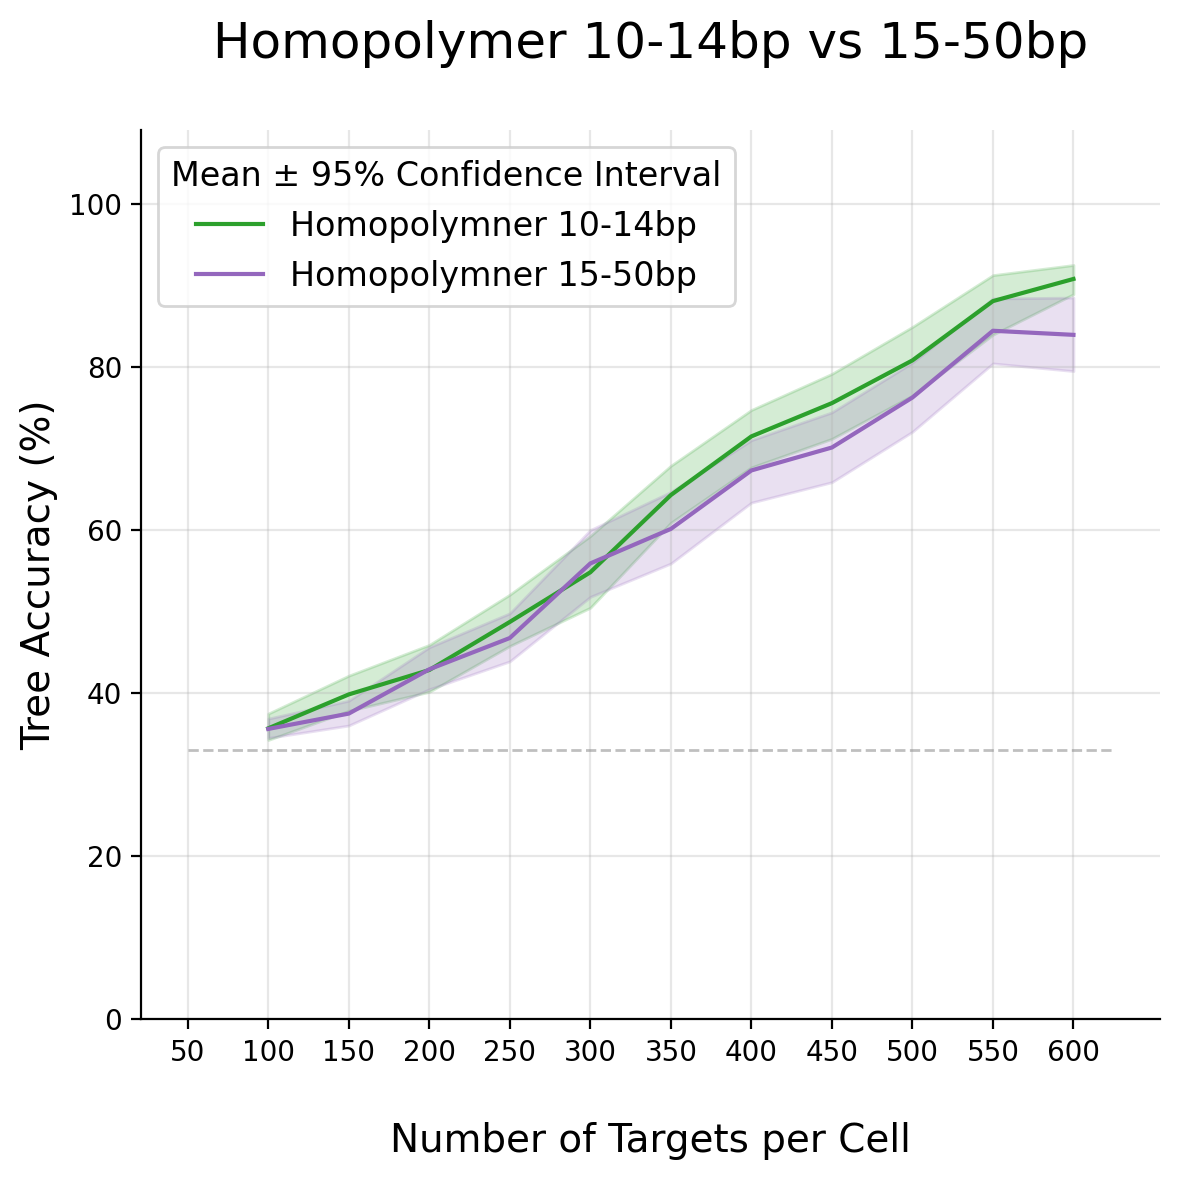

In [44]:
fig, ax = plt.subplots(figsize=(6,6), dpi=200)

# Define custom color palette: tab:green for first group, tab:purple for second group
custom_colors = ['tab:green', 'tab:purple']
sns.lineplot(data=df_combined_filtered, x='n_target', y='all_accuracy', hue='group', palette=custom_colors)

ax.set_title('Homopolymer 10-14bp vs 15-50bp\n', fontsize=18)
ax.set_ylabel('Tree Accuracy (%)', fontsize=14)
ax.set_xlabel('\nNumber of Targets per Cell', fontsize=14)

ax.grid(True, alpha=0.3)
ax.set_ylim(0,109)
ax.set_xticks(np.arange(50,601,50))

# Add horizontal reference line at 33% accuracy
ax.hlines(33, ax.get_xlim()[0], ax.get_xlim()[1], color='gray', linestyle='--', alpha=0.5, linewidth=1)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.legend(fontsize=12, loc="upper left", title="Mean ± 95% Confidence Interval", title_fontsize=12)
plt.tight_layout()
plt.savefig('Fig1_HCT116_homopolymer_downsample_accuracy.pdf', dpi=200)
plt.show()

# Regression analysis for more robust comparison

In [20]:
from scipy import stats

In [21]:
def calculate_regression_stats(df, group_name):
    """
    Calculate regression statistics for a specific group
    Returns: slope, intercept, r_squared, p_value, std_err
    """
    group_data = df[df['group'] == group_name]
    x = group_data['n_target'].values
    y = group_data['all_accuracy'].values
    
    # Linear regression using scipy
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
    r_squared = r_value ** 2
    
    return {
        'group': group_name,
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_squared,
        'p_value': p_value,
        'std_err': std_err,
        'n_points': len(x)
    }


In [22]:
# Calculate regression statistics for each group
regression_stats = []

for group in df_combined_filtered['group'].unique():
    stats_dict = calculate_regression_stats(df_combined_filtered, group)
    regression_stats.append(stats_dict)

print("Regression analysis completed for groups:", df_combined_filtered['group'].unique())


Regression analysis completed for groups: ['Homopolymner 10-14bp' 'Homopolymner 15-50bp']


In [23]:
# Display quantitative comparison table
regression_df = pd.DataFrame(regression_stats)
print("Quantitative Regression Analysis:")
print("="*60)
for _, row in regression_df.iterrows():
    print(f"\n{row['group']}:")
    print(f"  Slope: {row['slope']:.4f} (accuracy increase per target)")
    print(f"  R²: {row['r_squared']:.4f} (variance explained)")
    print(f"  P-value: {row['p_value']:.2e}")
    print(f"  Standard Error: {row['std_err']:.4f}")
    print(f"  Data Points: {row['n_points']}")


Quantitative Regression Analysis:

Homopolymner 10-14bp:
  Slope: 0.1186 (accuracy increase per target)
  R²: 0.7966 (variance explained)
  P-value: 1.86e-115
  Standard Error: 0.0033
  Data Points: 330

Homopolymner 15-50bp:
  Slope: 0.1068 (accuracy increase per target)
  R²: 0.7234 (variance explained)
  P-value: 1.46e-93
  Standard Error: 0.0036
  Data Points: 330


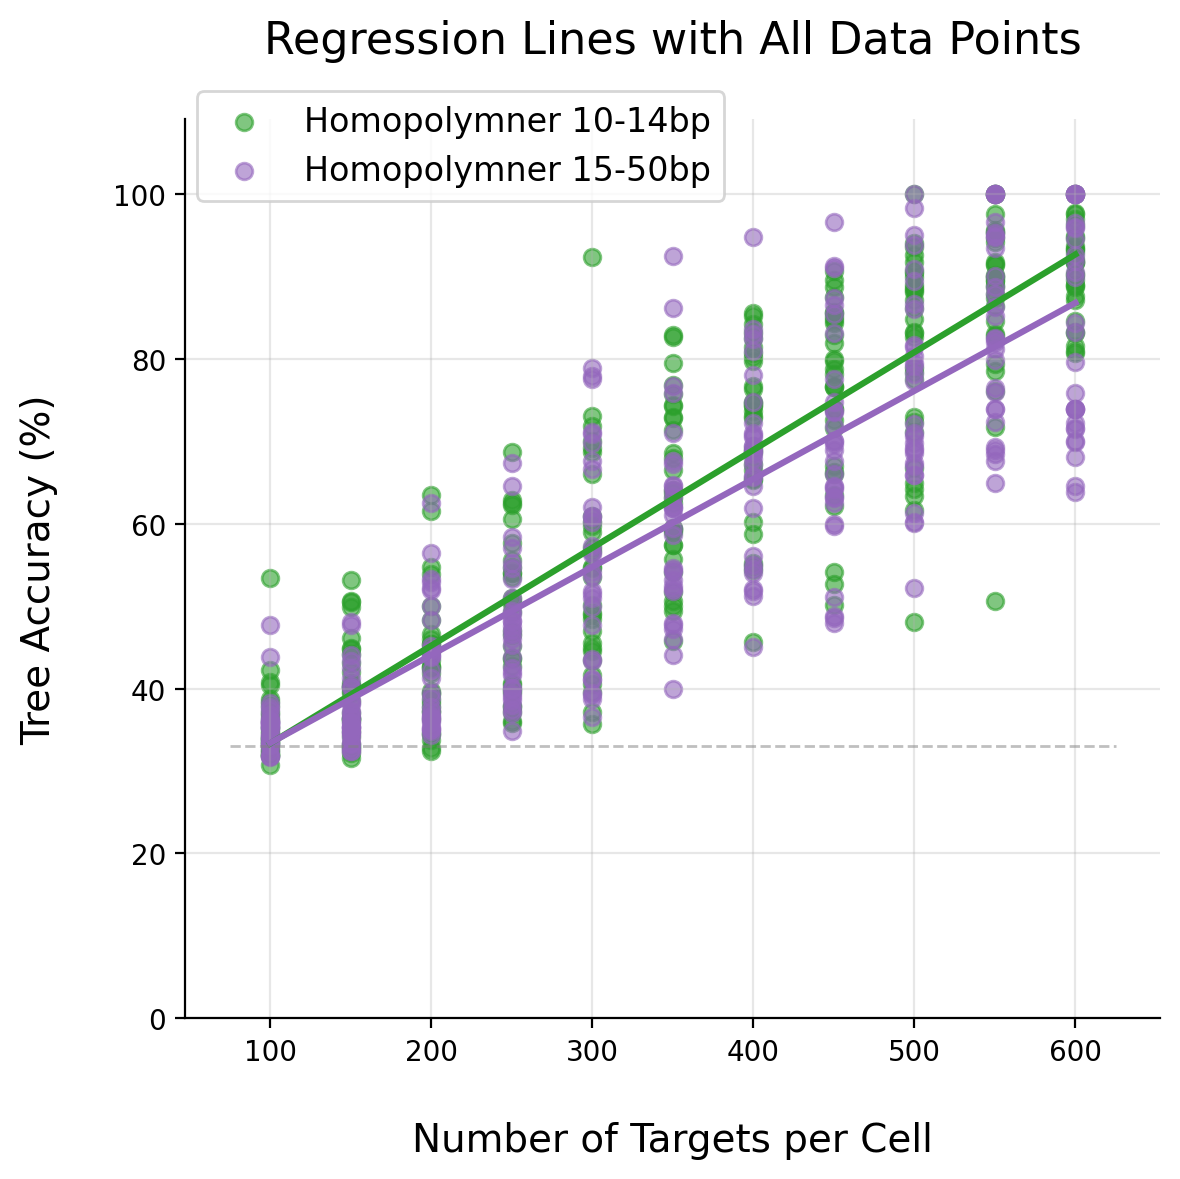

In [50]:
# Regression plot with all data points
fig, ax = plt.subplots(figsize=(6, 6), dpi=200)

# Define custom colors for each group
custom_colors = ['tab:green', 'tab:purple']
group_names = df_combined_filtered['group'].unique()

for i, group in enumerate(group_names):
    group_data = df_combined_filtered[df_combined_filtered['group'] == group]
    sns.regplot(data=group_data, x='n_target', y='all_accuracy', 
                label=group, ax=ax, scatter_kws={'alpha':0.6}, ci=None, color=custom_colors[i])

ax.set_title('Regression Lines with All Data Points\n', fontsize=16)
ax.set_ylabel('Tree Accuracy (%)\n', fontsize=14)
ax.set_xlabel('\nNumber of Targets per Cell', fontsize=14)

ax.grid(True, alpha=0.3)
ax.set_ylim(0, 109)

# Add horizontal reference line at 33% accuracy
ax.hlines(33, ax.get_xlim()[0], ax.get_xlim()[1], color='gray', linestyle='--', alpha=0.5, linewidth=1)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.legend(fontsize=12, bbox_to_anchor=(0.57, 1.05), title_fontsize=12) 
plt.tight_layout()
plt.savefig('Fig1_HCT116_homopolymer_downsample_accuracy_regression.pdf', dpi=200)
plt.show()

## Combined Plots


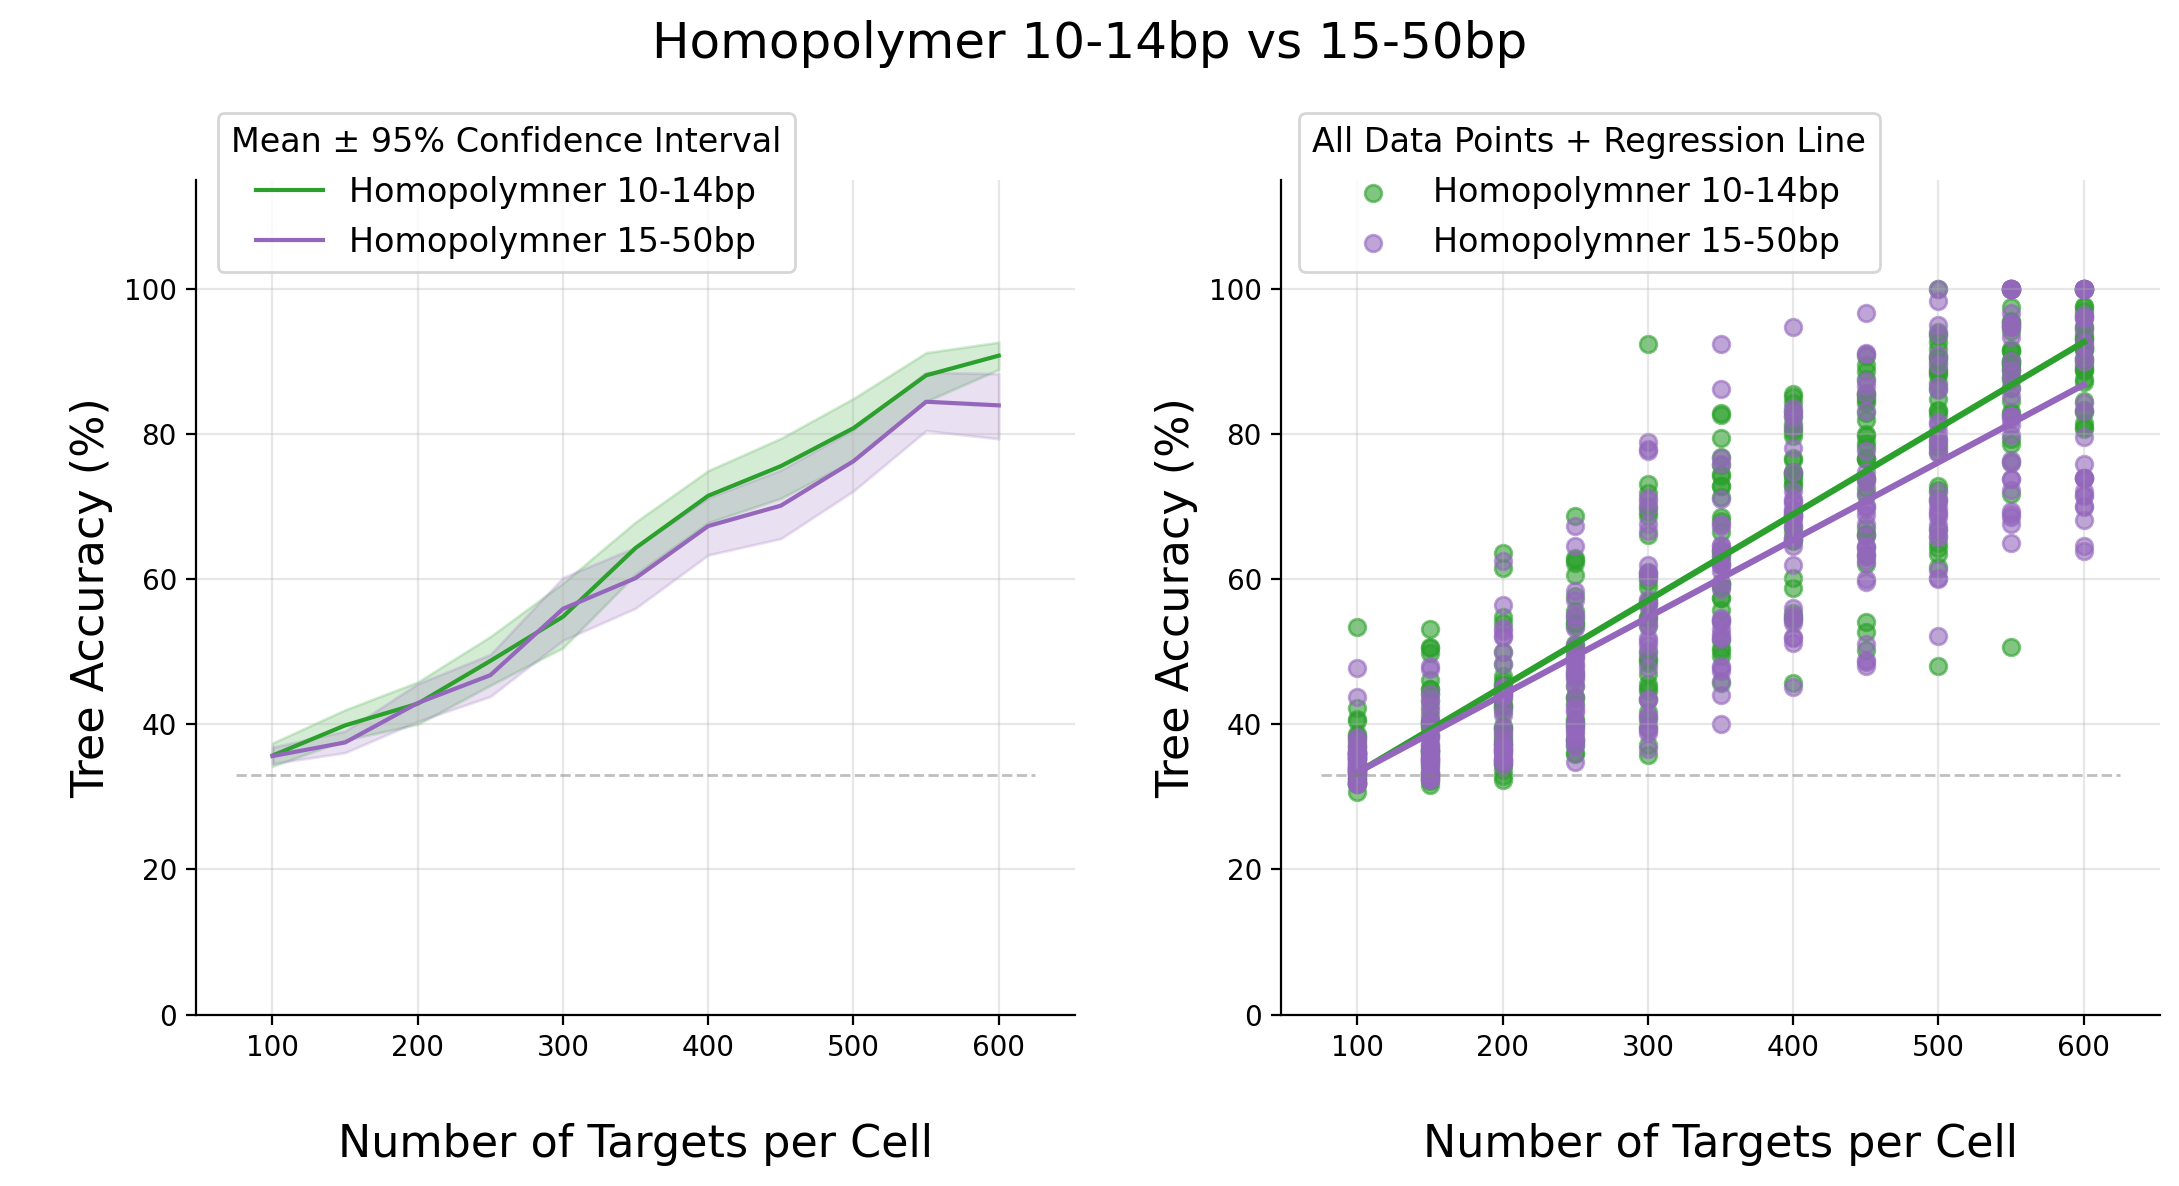

In [51]:
# Combined side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(11, 6), dpi=200)
fig.suptitle('Homopolymer 10-14bp vs 15-50bp', fontsize=18)

# Define custom color palette
custom_colors = ['tab:green', 'tab:purple']

# Left: Original lineplot (mean ± 95% CI)
sns.lineplot(data=df_combined_filtered, x='n_target', y='all_accuracy', hue='group', ax=axes[0], palette=custom_colors)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 115)
axes[0].legend(bbox_to_anchor=(0.7, 1.1), fontsize=12, title="Mean ± 95% Confidence Interval", title_fontsize=12)

# Right: Regression plot with all data points
group_names = df_combined_filtered['group'].unique()
for i, group in enumerate(group_names):
    group_data = df_combined_filtered[df_combined_filtered['group'] == group]
    sns.regplot(data=group_data, x='n_target', y='all_accuracy', 
                label=group, ax=axes[1], scatter_kws={'alpha':0.6}, ci=None, color=custom_colors[i])

axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 115)
axes[1].legend(bbox_to_anchor=(0.7, 1.1), fontsize=12, title="All Data Points + Regression Line", title_fontsize=12)

for ax in axes:
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.set_ylabel('\nTree Accuracy (%)', fontsize=16)
    ax.set_xlabel('\nNumber of Targets per Cell', fontsize=16)
    ax.hlines(33, ax.get_xlim()[0], ax.get_xlim()[1], color='gray', linestyle='--', alpha=0.5, linewidth=1)

plt.tight_layout()
plt.savefig('Fig1_HCT116_homopolymer_downsample_accuracy_10to14bp_combined.pdf', dpi=200)
plt.show()
